In [ ]:
################################################################
#### CODE FOR PROJEKT: DRAWDOWN ANALYSIS OF THE MSCI WORLD #####
################################################################

In [1]:
# import libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt, statsmodels.api as sm, yfinance as yf


In [2]:
# load data
data = yf.download("EUNL.DE", start="2015-01-01", end="2026-01-05", interval="1wk",progress=False, auto_adjust=True)
world = data["Close"]["EUNL.DE"]

In [3]:
#######################
# NUMBERS OF INDICATION
#######################

# preparation
drawdown = world/world.cummax()-1
underwater = drawdown<0
groups = (
    underwater
    !=
    underwater.shift()
).cumsum()

# worst drawdown
MDD = drawdown.min().round(2)

# percentage under water
TUW = underwater.mean().round(2)

# average drowdown
ADD = drawdown.mean().round(2)

# Average time under water
ATU = underwater.groupby(groups).sum().mean().round(2)

# Maximum Time under water
MTU = underwater.groupby(groups).sum().max()

ls = []

for s in underwater.groupby(groups).sum():
    if s > 0:
        ls.append(s)


info = (
f"Statistics\n\n"
f"Max Drawdown: {MDD:.1%}\n"
f"Time Under Water: {TUW:.1%}\n"
f"Longest Recovery: {MTU:.0f} weeks\n"
f"Average Recovery: {ATU:.0f} weeks"
)

# Probability of loss
weeks = np.arange(1,104,1)
prob = []
for w in weeks:
    prob.append(
        ((world.shift(-w)/world-1)<0).mean())
    


In [ ]:

########### CHARTS ################


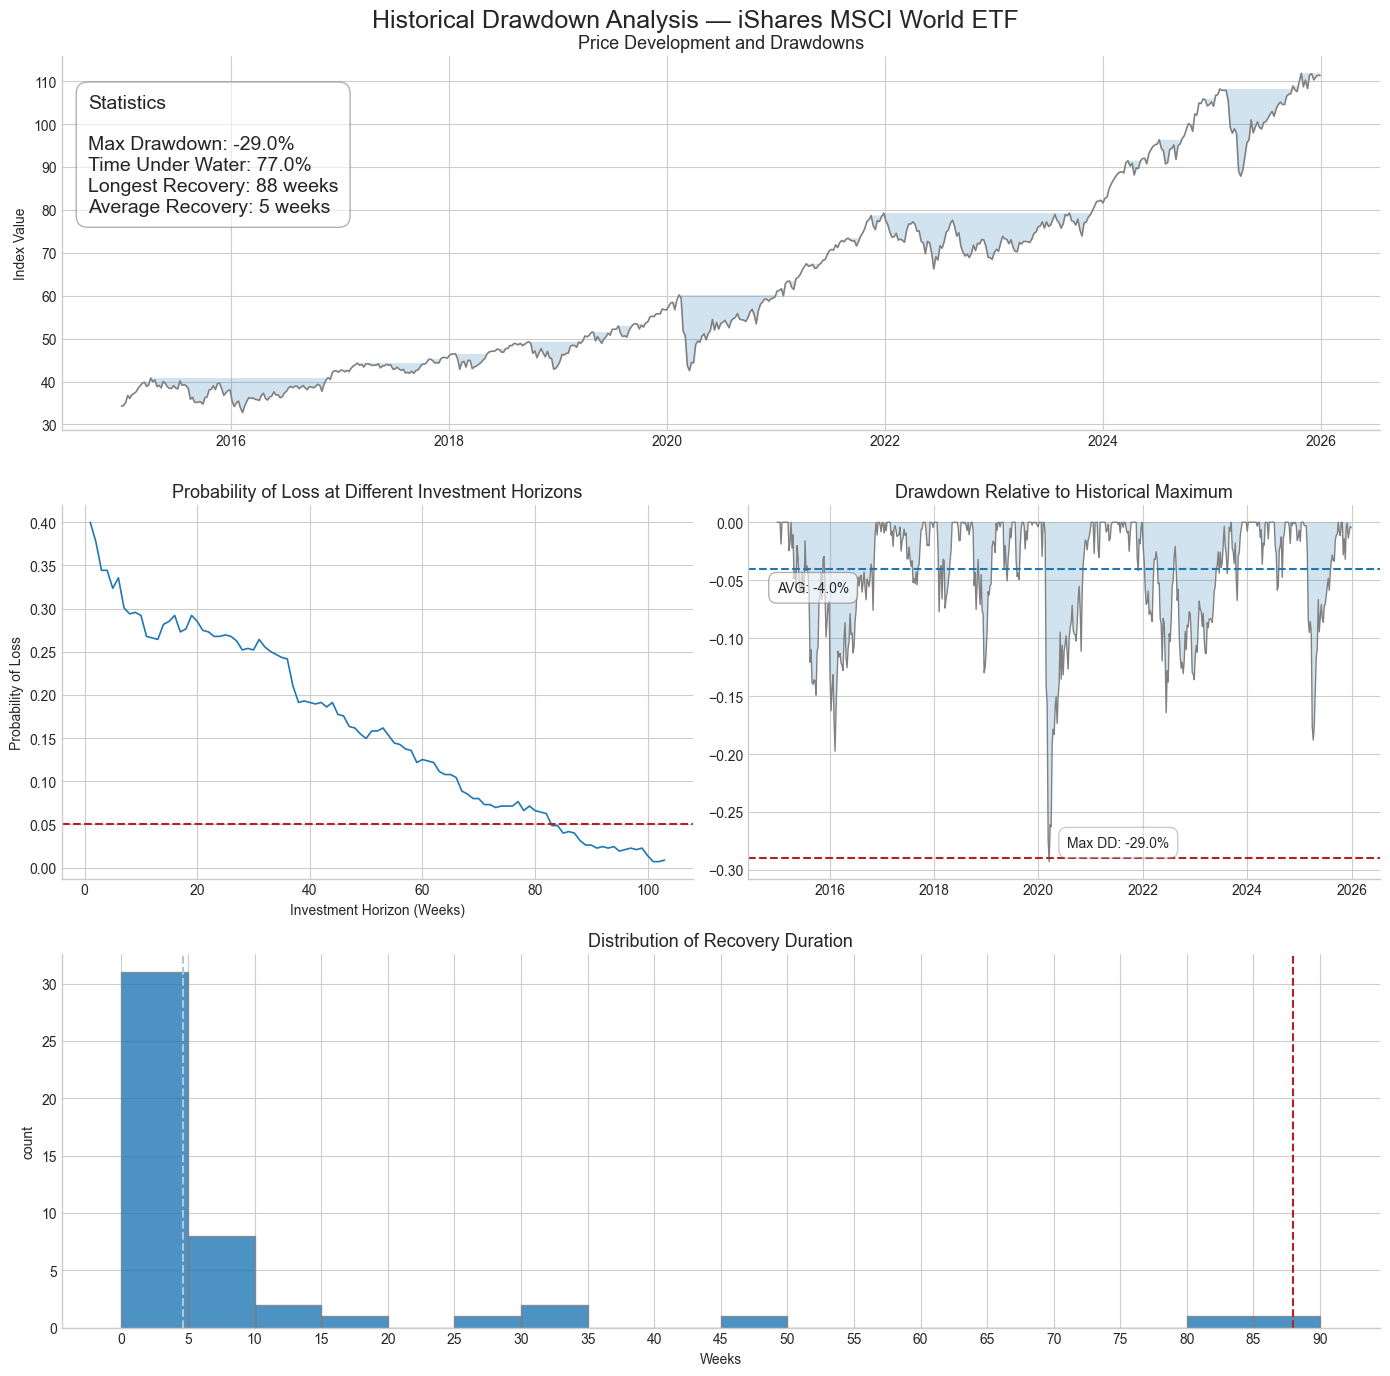

In [7]:
##############
# CHARTS 
##############
# set theme 
plt.style.use("seaborn-v0_8-whitegrid")
# set figure
fig = plt.figure(figsize = (14,14))
line = "grey"



##############################
# CHART 1 — PRICE + DRAWDOWN
##############################
ax1 = fig.add_subplot(3,1,1)
ax1.plot(world, color = line, lw = 1.2)
ax1.fill_between(world.index,world.cummax(),world, alpha=0.2)
ax1.text(
    0.02,          # x relativ
    0.90,          # y relativ
    info,transform = ax1.transAxes,fontsize=14,verticalalignment="top",bbox=dict(
        facecolor="white",
        edgecolor="grey",
        alpha=0.6,
        boxstyle="round,pad=0.6"))

ax1.set_title("Price Development and Drawdowns",fontsize=13)
ax1.set_ylabel("Index Value")



##############################
# CHART 2 - RISK OF LOSS
##############################
ax4 = fig.add_subplot(3,2,3)
ax4.plot(weeks, prob, lw=1.2)
ax4.axhline(0.05,linewidth = 1.5,color="firebrick",linestyle="dashed")
ax4.set_title("Probability of Loss at Different Investment Horizons", fontsize=13)
ax4.set_xlabel("Investment Horizon (Weeks)")
ax4.set_ylabel("Probability of Loss")


##############################
# CHART 3 — DRAWDOWN
##############################
ax2 = fig.add_subplot(3,2,4)
ax2.plot(drawdown, lw=1, color=line)
ax2.fill_between(
    drawdown.index,
    drawdown,
    0,
    alpha=0.2
)
ax2.axhline(MDD,linewidth = 1.5,color="firebrick",linestyle="dashed")
mdd_date = drawdown.idxmin()
ax2.annotate(
    f"Max DD: {MDD:.1%}",
    xy = (world.index[290], MDD+0.01),
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        alpha=0.4,
        boxstyle="round,pad=0.6"))
ax2.axhline(ADD,linewidth = 1.5,linestyle="dashed")
ax2.annotate(
    f"AVG: {ADD:.1%}",
    xy = (world.index[0], ADD-0.02),
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        alpha=0.6,
        boxstyle="round,pad=0.6"))
ax2.set_title("Drawdown Relative to Historical Maximum",fontsize=13)




##############################
# CHART 5 — RECOVERY LENGTH
##############################
ax3 = fig.add_subplot(3,1,3)
ax3.hist(ls,edgecolor = "grey",alpha = 0.8,bins =np.arange(0,max(ls)+5,5))
ax3.axvline(np.mean(underwater.groupby(groups).sum()),color="lightsteelblue",linestyle="dashed",lw=1.5)
ax3.axvline(max(ls),color="firebrick",linestyle="dashed",lw=1.5)
ax3.set_title("Distribution of Recovery Duration",fontsize=13)
ax3.set_xlabel("Weeks")
ax3.set_ylabel("count")
ax3.set_xticks(np.arange(0,95,5))


################
# CLEANUP 
################
for ax in [ax1,ax2,ax3,ax4]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Historical Drawdown Analysis — iShares MSCI World ETF",
    fontsize=18
)

plt.tight_layout()
plt.show()